### Feauture Engineering
- Feature engineering is a crucial step in preparing data for machine learning models, where raw features are transformed to improve model performance and accuracy. <br>

- They make sure that features with different ranges or units are transformed into a comparable scale so that models can learn effectively.

- Improve accuracy: 
 -- Choosing the right features helps the model learn better, leading to more accurate predictions.
- Reduce overfitting: 
-- Using fewer, more important features helps the model avoid memorizing the data and perform better on new data.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df=pd.read_csv("Train.csv")
df_num = df.select_dtypes(include=np.number)
df_cat=df.select_dtypes(exclude=np.number)
df_cat

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
0,D,Flight,low,F
1,F,Flight,low,M
2,A,Flight,low,M
3,B,Flight,medium,M
4,C,Flight,medium,F
...,...,...,...,...
10994,A,Ship,medium,F
10995,B,Ship,medium,F
10996,C,Ship,low,F
10997,F,Ship,medium,M


### New Feautures Discussion
1. Creating New Feautures        
2. Modifying existing Feautures              
3. Feauture Scaling and Transformation          


### Why Scaling?
- Each feauture has its own scale(range).<br>
- Model will think like higher number have higher proprity.so we have to do scaling.<br>
- Computtion is also high<br>
- Algorithms like Gradient descent,XGBoost,RandomeForest converges faster when the data is scaled.<br>




Scaling we can do it in 2 ways:

1.Standardization

- we make mean value of data to 0 and standard deviation to be 1. <br>
- If we have abnormal outliers then we can use Stndardization,because normalization uses max which effects the scaling.  <br>    
<b> x_new=(x-mean)/std  </b>    
<p>Deviation is distance from mean</p>

2.Normalization     <br> 
- brings values into a fixed range, usually [0,1]<br>
- Getting values from -1 to 1.<br>
<b>x_new=(x-x_min)/(x_max-x_min)   </b>

### Normalization
- Min-Max Scaling transforms features by subtracting the minimum value and dividing by the difference between the maximum and minimum values.
<br> 
- This method maps feature values to a specified range, commonly 0 to 1, preserving the original distribution shape but is <b>still affected by outliers due to reliance on extreme values.</b><br>

- Scales features to range<br>
- Sensitive to outliers because min and max can be skewed

In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Creates MinMaxScaler object to scale features to range.

scaler = MinMaxScaler()

#Fits scaler to data and transforms with scaler.fit_transform(df).
scaled_data = scaler.fit_transform(df_num)

#Converts result to DataFrame maintaining column names.
scaled_df = pd.DataFrame(scaled_data, columns=df_num.columns)

scaled_df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,0.000000,0.4,0.25,0.378505,0.125,0.671875,0.033893,1.0
1,0.000091,0.4,1.00,0.560748,0.000,0.906250,0.304894,1.0
2,0.000182,0.0,0.25,0.406542,0.250,0.734375,0.346676,1.0
3,0.000273,0.2,0.50,0.373832,0.250,0.140625,0.025712,1.0
4,0.000364,0.0,0.25,0.411215,0.125,0.703125,0.216654,1.0


In [ ]:
#By using Formula
new_df=pd.DataFrame()
for i in df_num.columns:
    new_df[i]=(df_num[i]-df_num[i].min())/(df_num[i].max()-df_num[i].min())

new_df

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,0.000000,0.4,0.25,0.378505,0.125,0.671875,0.033893,1.0
1,0.000091,0.4,1.00,0.560748,0.000,0.906250,0.304894,1.0
2,0.000182,0.0,0.25,0.406542,0.250,0.734375,0.346676,1.0
3,0.000273,0.2,0.50,0.373832,0.250,0.140625,0.025712,1.0
4,0.000364,0.0,0.25,0.411215,0.125,0.703125,0.216654,1.0
...,...,...,...,...,...,...,...,...
10994,0.999636,0.4,0.00,0.728972,0.375,0.000000,0.078451,1.0
10995,0.999727,0.4,0.00,0.635514,0.375,0.078125,0.035939,0.0
10996,0.999818,0.6,0.75,0.682243,0.375,0.046875,0.022498,0.0
10997,0.999909,0.6,0.25,0.593458,0.500,0.015625,0.030533,0.0


###  Standardization
- Standardization centers features by subtracting the mean and scales them by dividing by the standard deviation, transforming features to have zero mean and unit variance. 
- This assumption of normal distribution often benefits models like linear regression, logistic regression and neural networks by improving convergence speed and stability
- Produces features with mean 0 and variance 1.
- Effective for data approximately normally distributed.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)
scaled_df = pd.DataFrame(scaled_data,
                         columns=df_num.columns)
scaled_df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,-1.731893,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,0.822138
1,-1.731578,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,0.822138
2,-1.731263,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,0.822138
3,-1.730949,-0.923799,0.006689,-0.711529,0.283954,-0.208162,-1.502484,0.822138
4,-1.730634,-1.799887,-0.700755,-0.545074,-0.372735,2.013404,-0.703244,0.822138


In [ ]:
#By using Formula
new_df=pd.DataFrame()
for i in df_num.columns:
    new_df[i]=(df_num[i]-df_num[i].mean())/df_num[i].std()

new_df


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,-1.731815,-0.047709,-0.700723,-0.690690,-0.372718,1.889897,-1.468173,0.822100
1,-1.731500,-0.047709,1.421513,0.120740,-1.029377,2.815508,-0.333878,0.822100
2,-1.731185,-1.799806,-0.700723,-0.565855,0.283941,2.136727,-0.158995,0.822100
3,-1.730870,-0.923757,0.006689,-0.711496,0.283941,-0.208152,-1.502416,0.822100
4,-1.730555,-1.799806,-0.700723,-0.545049,-0.372718,2.013312,-0.703212,0.822100
...,...,...,...,...,...,...,...,...
10994,1.730555,-0.047709,-1.408135,0.869753,0.940601,-0.763518,-1.281672,0.822100
10995,1.730870,-0.047709,-1.408135,0.453635,0.940601,-0.454982,-1.459612,-1.216286
10996,1.731185,0.828339,0.714101,0.661694,0.940601,-0.578396,-1.515868,-1.216286
10997,1.731500,0.828339,-0.700723,0.266381,1.597260,-0.701811,-1.482237,-1.216286


### Feauture Selection
In machine learning, feature selection is the process of choosing the most important features (independent variables) from your dataset that contribute to predicting the target variable.<br>

This reduces overfitting, speeds up training, and often improves accuracy.

There are 3 main methods of feature selection:

1. Filter Methods (use statistical tests like Chi-square, ANOVA, correlation, etc.)<br>

2. Wrapper Methods (use machine learning models to evaluate subsets of features)<br>

3. Embedded Methods (selection happens during model training, e.g., LASSO, Decision Trees)
  

### Filter Methods
- Filter methods evaluate each feature independently with target variable. 
- Feature with high correlation with target variable are selected as it means this feature has some relation and can help us in making predictions. 
- These methods are used in the preprocessing phase to remove irrelevant or redundant features based on statistical tests (correlation) or other criteria.

### Correlation Coefficient?

Correlation measures the linear relationship between two variables.

In [18]:
a=df_num.corr()
for i in a:
    for j in a:
        if a[i][j]>0.5 and i!=j:
            print(i,j)

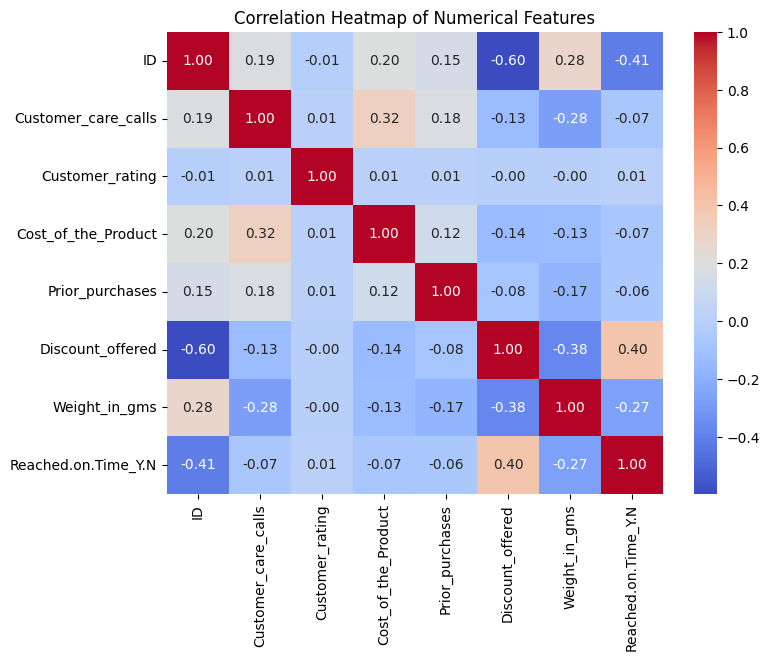

In [11]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(a, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### What is Chi-Square Test?

- It is a statistical test used to check the independence of two categorical variables.

- In Feature Selection, it helps us determine whether a categorical feature and the target variable are related.

- If they are dependent → the feature is important.

- If independent → the feature is not useful.

In [ ]:
import pandas as pd
from sklearn.feature_selection import chi2, SelectKBest

X = pd.get_dummies(df_cat) 
y = df['Reached.on.Time_Y.N']

# Apply Chi-Square Test
chi_scores, p_values = chi2(X, y)

# Display results
for feature, score, p in zip(X.columns, chi_scores, p_values):
    print(f"Feature: {feature}, Chi2 Score: {score:.2f}, p-value: {p:.4f}")

Feature: Warehouse_block_A, Chi2 Score: 0.80, p-value: 0.3724
Feature: Warehouse_block_B, Chi2 Score: 0.24, p-value: 0.6250
Feature: Warehouse_block_C, Chi2 Score: 0.00, p-value: 0.9899
Feature: Warehouse_block_D, Chi2 Score: 0.01, p-value: 0.9367
Feature: Warehouse_block_F, Chi2 Score: 0.05, p-value: 0.8259
Feature: Mode_of_Shipment_Flight, Chi2 Score: 0.18, p-value: 0.6746
Feature: Mode_of_Shipment_Road, Chi2 Score: 0.54, p-value: 0.4609
Feature: Mode_of_Shipment_Ship, Chi2 Score: 0.02, p-value: 0.8782
Feature: Product_importance_high, Chi2 Score: 11.11, p-value: 0.0009
Feature: Product_importance_low, Chi2 Score: 0.34, p-value: 0.5626
Feature: Product_importance_medium, Chi2 Score: 0.77, p-value: 0.3804
Feature: Gender_F, Chi2 Score: 0.12, p-value: 0.7291
Feature: Gender_M, Chi2 Score: 0.12, p-value: 0.7270



- point estimate :telling exact number
- interval estimate : telling or keep a range
we work on point estimate only.

### Hypothesis Testing
Claim or assumption

Hypothesis: Claim/Statement of being tested by scientific method.

we have to prove the claim/statements by scentific methods 

Null Hypothesis and Alternate Hypothesis
Null Hypothesis  
You are proving it for a sample 
so we have Level of significnce and confidence.
 
 95% LOS means -> 100 people 95 people would be cured by the drug.
 out of 100 experiments 95 are succesful.

 LOS->Error rate
 confiden

z-test  ->  sample size n>=30

T Test -> n<30 

chi squared test ->Data is categorical we use chi squaared test.

Anova Test -> compare means of 3 or more groups.

F-Test -> compare variances across 2 groups.

### Wrapper Methods

Wrapper methods treat feature selection as a search problem:

1. Select a subset of features.

2. Train a model (e.g., logistic regression, decision tree).

3. Evaluate performance (accuracy, F1-score, RMSE, etc.).

4. Repeat for different subsets.

5. Choose the best-performing feature subset.

Keep or discard features based on accuracy/performance.

Unlike filter methods (which rely only on statistics), wrapper methods actually train models to find the best subset.

### Forward Selection

1. Start with no features.

2. Add features one by one.

3. At each step, keep the feature that improves the model the most.

4. Stop when performance stops improving.

✅ Good when you have fewer features.
❌ Can miss interactions between features.

### Backward Elimination

1. Start with all features.

2. Remove the least important feature one by one.

3. Continue until removing features decreases model performance.

✅ Good when features are many.
❌ Very computationally expensive.

### Recursive Feature Elimination (RFE)

1. Train a model and rank features by importance (weights, coefficients).

2. Remove the least important feature(s).

3. Repeat recursively until you reach the desired number of features.

✅ More systematic, widely used.
❌ Still computationally heavy.

In [1]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Load data
X, y = load_iris(return_X_y=True)

# Model
model = LogisticRegression(max_iter=1000)

# Recursive Feature Elimination (select top 2 features)
rfe = RFE(model, n_features_to_select=2)
fit = rfe.fit(X, y)

print("Selected Features:", fit.support_)
print("Feature Ranking:", fit.ranking_)


Selected Features: [False False  True  True]
Feature Ranking: [3 2 1 1]


### Embedded Methods

Embedded methods are feature selection techniques that happen during the training of a machine learning model itself.

Unlike filter methods (which use only statistics) and wrapper methods (which train multiple models on subsets), embedded methods perform feature selection as part of the model learning process.

In simple words: <b> the model automatically decides which features are important while it is being trained. </b>
Examples:
1. LASSO (L1 Regularization)
2. Ridge (L2 Regularization)
3. Elastic Net
4. Decision Trees / Random Forest / XGBoost

### Label Encoding

- Label Encoding is a technique to convert categorical values into numeric labels (integers).

- Each unique category is assigned a number.

- Unlike One-Hot Encoding, it does not create extra columns.<br>
Example 
Red	->2<br>
Blue->0<br>
Green->1<br>

## When to Use?

- Ordinal categorical data (where order matters).

Example: Education level → High School (0), Bachelor’s (1), Master’s (2), PhD (3)

- Avoid for purely nominal data (like country, color) → use One-Hot Encoding instead.

### Advantages

- Very simple and memory efficient (only one column).

- Best for ordinal data (like rankings).

### Disadvantages

- Introduces artificial order for nominal categories (e.g., “Red=2, Blue=0, Green=1”).

- Some ML models may wrongly assume higher numbers mean “greater importance”.

In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.DataFrame({"Color": ["Zed", "Blue", "Green", "Red"]})

encoder = LabelEncoder()
df["Color_encoded"] = encoder.fit_transform(df["Color"])

df


,Color,Color_encoded
0,Zed,3
1,Blue,0
2,Green,1
3,Red,2


### One-Hot Encoding

One-hot encoding is a technique to convert categorical variables (labels/text) into a numerical form so that machine learning models can use them.

- Each unique category becomes a new binary column (0/1).

- 1 means the row belongs to that category, 0 means it doesn’t.

## Why Do We Need It?

- ML models can’t directly handle text like "Red" or "Blue".

- One-hot encoding turns categories into numbers without introducing any order or ranking (unlike Label Encoding).

- Prevents models from misinterpreting categories as numeric values.

In [ ]:
#using pandas
import pandas as pd

df = pd.DataFrame({"Color": ["Red", "Blue", "Green", "Red"]})
encoded = pd.get_dummies(df, columns=["Color"])
encoded

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True


In [11]:
## Using Scikit-learn
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

df = pd.DataFrame({"Color": ["Red", "Blue", "Green", "Red"]})

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[["Color"]])

print(encoded)
print(encoder.get_feature_names_out())


[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
['Color_Blue' 'Color_Green' 'Color_Red']


In [10]:
df_encoded = pd.DataFrame(encoded,columns = encoder.get_feature_names_out(['Color']))
df = pd.concat([df,df_encoded],axis=1)
df

,Color,Color_Green,Color_Red
0,Red,0.0,1.0
1,Blue,0.0,0.0
2,Green,1.0,0.0
3,Red,0.0,1.0


If Color_Blue = 0 and Color_Green = 0, then we automatically know Color_Red = 1.

This means one column is a linear combination of the others:

- Color_Red=1−(Color_Blue+Color_Green)

This perfect correlation = multicollinearity.
### What is Multicollinearity?

Multicollinearity means two or more independent variables (features) in a dataset are highly correlated.

- In other words: one feature can be predicted from another.

- This makes it hard for models (like Linear Regression or Logistic Regression) to figure out which feature is truly affecting the target.

<b> Solution </b>

Drop one dummy column (drop="first" in OneHotEncoder, or drop_first=True in pd.get_dummies()).

In [13]:
#using pandas
import pandas as pd

df = pd.DataFrame({"Color": ["Red", "Blue", "Green", "Red"]})
encoded = pd.get_dummies(df, columns=["Color"],drop_first=True)
encoded

,Color_Green,Color_Red
0,False,True
1,False,False
2,True,False
3,False,True


In [14]:
## Using Scikit-learn
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

df = pd.DataFrame({"Color": ["Red", "Blue", "Green", "Red"]})

encoder = OneHotEncoder(sparse_output=False,drop="first")
encoded = encoder.fit_transform(df[["Color"]])

print(encoded)
print(encoder.get_feature_names_out())


[[0. 1.]
 [0. 0.]
 [1. 0.]
 [0. 1.]]
['Color_Green' 'Color_Red']


c:\Users\Ramu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


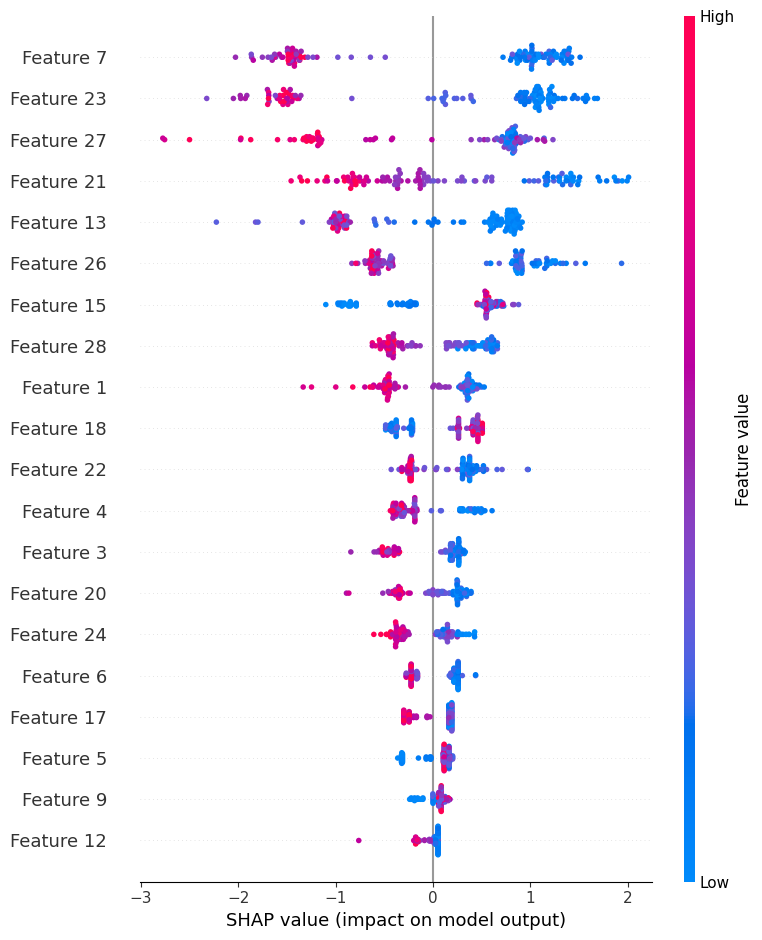

In [6]:
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Load dataset
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = xgb.XGBClassifier().fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Visualize feature importance
shap.summary_plot(shap_values, X_test)


In [4]:
!pip install shap

  Using cached shap-0.48.0-cp310-cp310-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.62.1-cp310-cp310-win_amd64.whl.metadata (2.9 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.45.1-cp310-cp310-win_amd64.whl.metadata (5.0 kB)
Using cached shap-0.48.0-cp310-cp310-win_amd64.whl (544 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.62.1-cp310-cp310-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.45.1-cp310-cp310-win_amd64.whl (38.1 MB)
Using cached cloudpickle-3.1.1-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/5 [slicer]
   ---------------------------------------- 0/5 [slicer]
   ---------------------------------------- 0/5 [slicer]
   ---------------------------------------- 0/5 [slicer]
   ---------------------------------------- 0/5 [slicer]
   ---------------------------------------- 0/5 [slicer]
   -------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Ramu\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\llvmlite\\binding\\llvmlite.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Before applying SMOTE
print("Before SMOTE:", Counter(y_train))

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and resample
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# After applying SMOTE
print("After SMOTE:", Counter(y_train_res))


In [7]:
# 1. Import required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

# 2. Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 3. Make dataset imbalanced (just for demonstration)
# We’ll keep fewer 'malignant' samples to simulate imbalance
X = X[y == 0].append(X[y == 1].sample(100, random_state=42))
y = y[y == 0].append(y[y == 1].sample(100, random_state=42))

print("Class distribution before split:", Counter(y))

# 4. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Before SMOTE:", Counter(y_train))

# 5. Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_res))

# 6. Train Logistic Regression model
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_res, y_train_res)

# 7. Predict on test data
y_pred = model.predict(X_test)

# 8. Evaluate performance
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


AttributeError: 'DataFrame' object has no attribute 'append'